In [9]:
import os, sys 
import h5py
import numpy as np 
import scipy.signal
import scipy.io as spio
from utils import *
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

## Data preparation

The cells below are used to process the dataset from Camargo et al [1] in order to extract the straight line locomotion segments. These steps are highly dependent on the dataset you investigated but the end goal is the same: having a single matrix containing all the straight line locomotion bouts from your dataset.

In [10]:
# Loading the data 
path_to_data = os.path.join(os.getcwd(), 'data_humans','sample_data.mat')
input_data = h5py.File(path_to_data,'r')['markers_matrix'][:]


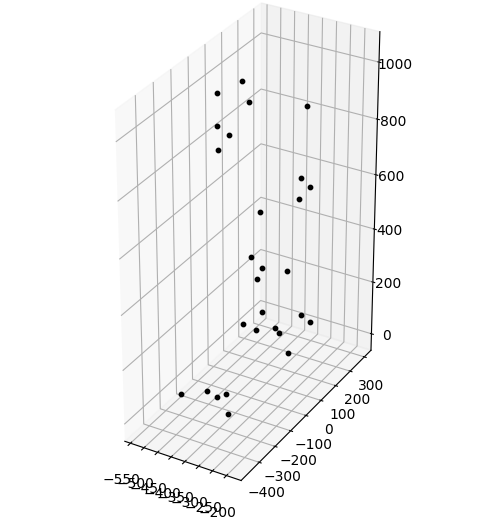

In [67]:
fig, axs = plt.subplots(1,1,figsize=(5,5),subplot_kw={'projection':'3d'})
axs.spines[['top','right']].set_visible(False)
for marker in range(28):
    axs.scatter(input_data[2,marker,0], input_data[0,marker,0],input_data[1,marker,0],color='k',s=10)
axs.set_aspect('equal')
plt.tight_layout()
plt.show()

### Selecting the straight lines locomotion bouts

We only select the straight line locomotion bouts (here in black highline). 

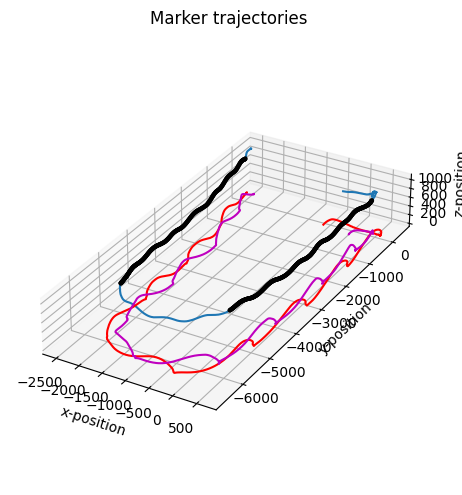

In [12]:
com_marker = np.nanmean(input_data[:,0:4,:],axis=1)
right_foot_marker = input_data[:,24,:]
left_foot_marker = input_data[:,20,:]

marker_matrix = np.concatenate((np.expand_dims(com_marker,-1), np.expand_dims(right_foot_marker,-1), np.expand_dims(left_foot_marker,-1)),axis=-1)

# Compute the marker velocity
dt = 1/200
com_velocity, right_foot_velocity, left_foot_velocity = np.zeros(com_marker.shape), np.zeros(right_foot_marker.shape), np.zeros(left_foot_marker.shape)
com_velocity[:,2:-2] = (com_marker[:,:-4]-8*com_marker[:,1:-3]+8*com_marker[:,3:-1]-com_marker[:,4:]) / (12 * dt)
right_foot_velocity[:,2:-2] = (right_foot_marker[:,:-4]-8*right_foot_marker[:,1:-3]+8*right_foot_marker[:,3:-1]-right_foot_marker[:,4:])/(12*dt)
left_foot_velocity[:,2:-2] = (left_foot_marker[:,:-4]-8*left_foot_marker[:,1:-3]+8*left_foot_marker[:,3:-1]-left_foot_marker[:,4:])/(12*dt)

angle_movements = np.zeros((com_velocity.shape[1],1))
angle_movements = np.arctan2(com_velocity[2,2:-2], com_velocity[0,2:-2])

bool_vector = extractStraightLineSegments(angle_movements)
idx_kept = np.where((bool_vector==1))[0]


fig, axs = plt.subplots(1,1,figsize=(5,5), subplot_kw={'projection':'3d'})
fig.suptitle('Marker trajectories')
axs.spines[['top','right']].set_visible(False)
axs.plot(com_marker[0,:],com_marker[2,:], com_marker[1,:])
axs.scatter(com_marker[0,idx_kept],com_marker[2,idx_kept], com_marker[1,idx_kept],s=5, color='k')
axs.plot(left_foot_marker[0,:],left_foot_marker[2,:],left_foot_marker[1,:],'r')
axs.plot(right_foot_marker[0,:],right_foot_marker[2,:],right_foot_marker[1,:],'m')
axs.set_xlabel('x-position'), axs.set_ylabel('y-position'), axs.set_zlabel('z-position') 
axs.set_aspect('equal')
plt.tight_layout()
plt.show()

### Rotating the data

In [68]:

idx_begin_chunk = np.where(np.diff(bool_vector.flatten())==1)[0]
idx_end_chunk = np.where(np.diff(bool_vector.flatten())==-1)[0]
total_data = np.full((3,1,3),np.nan)
for chunk in range(2):
      avg_angle = np.nanmean(angle_movements[idx_begin_chunk[chunk]:idx_end_chunk[chunk]])
      time_vector = np.arange(idx_begin_chunk[chunk], idx_end_chunk[chunk])
      rotated_data = rotate_data(marker_matrix, avg_angle, time_vector)
      total_data = np.concatenate((total_data, rotated_data, np.full((3,1,3),np.nan)), axis=1)

(3, 1230, 3)


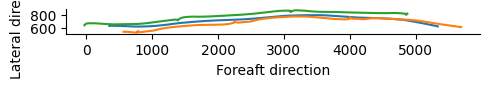

In [69]:
idx_nans = np.where(np.isnan(total_data[0,:,0]))[0]
print(total_data.shape)
fig, axs = plt.subplots(1,1,figsize=(5,5))
axs.spines[['top','right']].set_visible(False)
axs.plot(total_data[0,idx_nans[0]+1:idx_nans[1],0], total_data[2,idx_nans[0]+1:idx_nans[1],0])
axs.plot(total_data[0,idx_nans[0]+1:idx_nans[1],1], total_data[2,idx_nans[0]+1:idx_nans[1],1])
axs.plot(total_data[0,idx_nans[0]+1:idx_nans[1],2], total_data[2,idx_nans[0]+1:idx_nans[1],2])
axs.set_aspect('equal')
axs.set_xlabel('Foreaft direction'), axs.set_ylabel('Lateral direction')
plt.tight_layout()
plt.show()

The resulting trajectories should look very *flat* on the plot above. This results from the fact that the variability is way larger in the movement direction than in the one orthonormal to it.

## Gait segmentation

### Extracting foot contacts

Assuming you only have access to the foreaft and lateral positions of the foot and body markers (which is often the case in animal studies). You can extract the contacts initiation and termination of each foot based on the maxima and minima, respectively, of the foreaft distance between the com marker and the foot marker. 

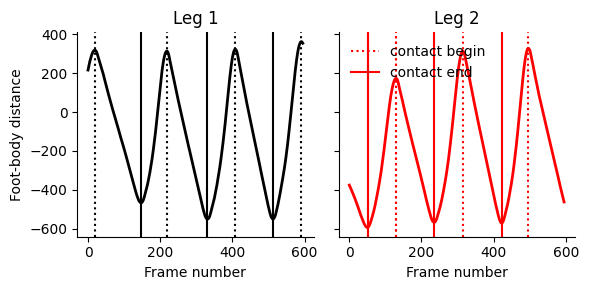

In [60]:
# Computing the foot contacts (assuming two dimensional data only) - and representing them
diff_leg1 = total_data[0,idx_nans[0]+1:idx_nans[1],1] - total_data[0,idx_nans[0]+1:idx_nans[1],0]
diff_leg2 = total_data[0,idx_nans[0]+1:idx_nans[1],2] - total_data[0,idx_nans[0]+1:idx_nans[1],0]
# The distance parameters is often mandatory to avoid identifying false contacts base of noise. The values should be setup to approximately half the number of frames of the gait cycle which can be evaluted visually.
peaks_leg1, _ = scipy.signal.find_peaks(diff_leg1, distance=150)
neg_peaks_leg1, _ = scipy.signal.find_peaks(-diff_leg1, distance=150)
peaks_leg2, _ = scipy.signal.find_peaks(diff_leg2, distance=150)
neg_peaks_leg2, _ = scipy.signal.find_peaks(-diff_leg2, distance=150)



fig, axs = plt.subplots(1,2,figsize=(6,3),sharex=True, sharey=True)
axs[0].spines[['top','right']].set_visible(False)
axs[1].spines[['top','right']].set_visible(False)
axs[0].set_title('Leg 1')
axs[1].set_title('Leg 2')
for p_1 in peaks_leg1:
    axs[0].axvline(p_1, color='k', ls=':')
for p_2 in peaks_leg2:
    axs[1].axvline(p_2, color='r', ls=':')
for p_1 in neg_peaks_leg1:
    axs[0].axvline(p_1, color='k')
for p_2 in neg_peaks_leg2:
    axs[1].axvline(p_2, color='r')
axs[1].axvline(peaks_leg2[0],color='r',ls=':',label='contact begin')
axs[1].axvline(neg_peaks_leg2[0],color='r',label='contact end')
axs[1].legend(frameon=False)
axs[0].plot(total_data[0,idx_nans[0]+1:idx_nans[1],1] - total_data[0,idx_nans[0]+1:idx_nans[1],0],'k',lw=2)
axs[1].plot(total_data[0,idx_nans[0]+1:idx_nans[1],2] - total_data[0,idx_nans[0]+1:idx_nans[1],0],'r',lw=2)
axs[0].set_ylabel('Foot-body distance'), axs[0].set_xlabel('Frame number'), axs[1].set_xlabel('Frame number')
plt.tight_layout()
plt.show()

### Gait segmentation itself

For the gait segmentation itself we proceed as follows 

1. Identify every heel strike of each foot based on the method above
2. For each of these heel strikes 
    - Verify if there is a next heel strike (if not discard)
    - Define the interval between current and next heel strike as the gait cycle
    - Search the contact of the contralateral limb within that gait cycle (if none was found, discard because unexploitable)
3. If this is a valid cycle (i.e. it contains a contact of the contralateral foot), use the contralateral foot contact location as the local spatial reference.
4. Using that reference, extracts the local kinematics of the COM and swing leg.
5. Interpolate this kinematics on a fixed grid (we recommend something which is around or below the average number of frames in a gait cycle)

In [61]:
# Gait segmentation - 
idx_nans = np.where(np.isnan(total_data[0,:,0]))[0]
tot_input_pelvis1 = np.zeros((1,101,6))
tot_input_leg1 = np.zeros((1,101,6))
timing_leg1 = np.zeros((1,1))
timings_step1 = np.zeros((1,1))
tot_input_pelvis2 = np.zeros((1,101,6))
tot_input_leg2 = np.zeros((1,101,6))
timing_leg2 = np.zeros((1,1))
timings_step2 = np.zeros((1,1))


for ii in range(len(idx_nans)-1):
    local_matrix = total_data[:,idx_nans[ii]+1:idx_nans[ii+1],:]
    local_matrix = compute_velocity(local_matrix)


    # 1. Identifying the heel strike and toe off
    ############################################
    diff_leg1 = local_matrix[0,:,1] - local_matrix[0,:,0]
    diff_leg2 = local_matrix[0,:,2] - local_matrix[0,:,0]
    b,a = scipy.signal.butter(6,20/100,btype='lowpass')
    diff_leg1 = scipy.signal.filtfilt(b,a,diff_leg1)
    diff_leg2 = scipy.signal.filtfilt(b,a,diff_leg2)
    
    # Find heel strike (max) and toe off (min) of the first leg
    hs_leg1, _ = scipy.signal.find_peaks(diff_leg1, distance=50)
    to_leg1, _ = scipy.signal.find_peaks(-diff_leg1, distance=50)

    # Find heel strike (max) and toe off (min) of the second leg 
    hs_leg2, _ = scipy.signal.find_peaks(diff_leg2, distance=50)
    to_leg2, _ = scipy.signal.find_peaks(-diff_leg2, distance=50)

    # Extract the gait cycles associated with the first leg contact 
    for idx in range(len(hs_leg1)-1):
        # 2. Identify the interleaved contact of the contralateral limb
        ###############################################################
        idx_middle = np.where((hs_leg2>hs_leg1[idx]) & (hs_leg2<hs_leg1[idx+1]))[0]
        if len(idx_middle)!=0:
            dist = hs_leg1[idx+1] - hs_leg1[idx]
            local_dist = np.arange(hs_leg2[idx_middle[0]], hs_leg1[idx+1])
            # 3. Defining the local reference 
            #################################
            local_ref = local_matrix[:,hs_leg2[idx_middle[0]],2]
            input_idx = np.arange(hs_leg1[idx], hs_leg1[idx+1])
            # 4. Extracting the local kinematics of the pelvis and swing foot
            #################################################################
            input_pelvis = local_matrix[:,input_idx,0]
            input_leg = local_matrix[:,input_idx,1]
            local_time = np.linspace(0,len(input_idx),101)
            local_interpolation_pelvis = np.zeros((1,101,6))
            local_interpolation_leg = np.zeros((1,101,6))
            # 5. Linear interpolation of the kinematics on a fixed grid  (here 101)
            #######################################################################
            for dim in range(6):
                if dim<3: # interpolation for the x-y-z positions requires to subtract the local reference
                    local_interpolation_pelvis[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_pelvis[dim,:]) - local_ref[dim]
                    local_interpolation_leg[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_leg[dim,:]) - local_ref[dim]
                else: # no need for the spatial normalization of the velocity
                    local_interpolation_pelvis[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_pelvis[dim,:])
                    local_interpolation_leg[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_leg[dim,:])
            tot_input_pelvis1 = np.concatenate((tot_input_pelvis1, local_interpolation_pelvis),0)
            tot_input_leg1 = np.concatenate((tot_input_leg1, local_interpolation_leg),0)
            tmp_time = np.zeros((1,1))
            tmp_step = np.zeros((1,1))
            tmp_time[0] = len(input_idx)
            tmp_step[0] = len(local_dist)
            timing_leg1 = np.concatenate((timing_leg1, tmp_time),0)
            timings_step1 = np.concatenate((timings_step1, tmp_step),0)

    # Extract the gait cycles associated with the second leg contact 
    for idx in range(len(hs_leg2)-1):
        idx_middle = np.where((hs_leg1>hs_leg2[idx]) & (hs_leg1<hs_leg2[idx+1]))[0]
        if len(idx_middle)!=0:
            dist = hs_leg2[idx+1] - hs_leg2[idx]
            local_dist = np.arange(hs_leg1[idx_middle[0]], hs_leg2[idx+1])
            local_ref = local_matrix[:,hs_leg1[idx_middle[0]],1]
            input_idx = np.arange(hs_leg2[idx], hs_leg2[idx+1])
            input_pelvis = local_matrix[:,input_idx,0]
            input_leg = local_matrix[:,input_idx,2]
            local_time = np.linspace(0,len(input_idx),101)
            local_interpolation_pelvis = np.zeros((1,101,6))
            local_interpolation_leg = np.zeros((1,101,6))
            for dim in range(6):
                if dim<3: # interpolation for the x-y-z positions requires to subtract the local reference
                    local_interpolation_pelvis[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_pelvis[dim,:]) - local_ref[dim]
                    local_interpolation_leg[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_leg[dim,:]) - local_ref[dim]
                else: # no need for the spatial normalization of the velocity
                    local_interpolation_pelvis[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_pelvis[dim,:])
                    local_interpolation_leg[0,:,dim] = np.interp(local_time, np.arange(0,len(input_idx)), input_leg[dim,:])
            tot_input_pelvis2 = np.concatenate((tot_input_pelvis2, local_interpolation_pelvis),0)
            tot_input_leg2 = np.concatenate((tot_input_leg2, local_interpolation_leg),0)
            tmp_time = np.zeros((1,1))
            tmp_step = np.zeros((1,1))
            tmp_time[0] = len(input_idx)
            tmp_step[0] = len(local_dist)
            timing_leg2 = np.concatenate((timing_leg2, tmp_time),0)
            timings_step2 = np.concatenate((timings_step2, tmp_step),0)


### Representation of the gait segmentated kinematics

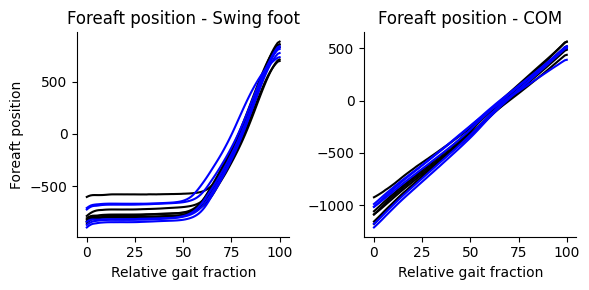

In [53]:
fig, axs = plt.subplots(1,2,figsize=(6,3))
axs[0].spines[['top','right']].set_visible(False)
for ii in range(1,7):
    axs[0].plot(tot_input_leg1[ii,:,0],'k')
for jj in range(1,6):
    axs[0].plot(tot_input_leg2[jj,:,0],'b')

axs[1].spines[['top','right']].set_visible(False)
for ii in range(1,7):
    axs[1].plot(tot_input_pelvis1[ii,:,0],'k')
for jj in range(1,6):
    axs[1].plot(tot_input_pelvis2[jj,:,0],'b')

axs[0].set_title('Foreaft position - Swing foot')
axs[1].set_title('Foreaft position - COM')
axs[0].set_xlabel('Relative gait fraction'),axs[1].set_xlabel('Relative gait fraction') 
axs[0].set_ylabel('Foreaft position')
plt.tight_layout()
plt.show()

**Remarks**

The code used to perform foot placement prediction assumes that the input data has the following form : 

- tot_input_pelvis (kinematics of the COM) : n_data_point x n_interp x 4 (x-, y- positions followed by x-, y- velocities)
- tot_input_leg (kinematics of the swinging foot) : n_data_point x n_interp x 4 (x-, y- positions followed by x-, y- velocities)

The subscript 1 and 2 correspond to gait cycles obtained by segmenting the gait based on different contacts (ie. right vs left leg).

We used the following function to transform these gait segmented data into inputs and outputs of our foot placement controller. 


In [ ]:
def get_input_output_fr(matrix_body, matrix_leg):
    """
    Get the input / output data for the fot placement controller
    """
    tot_input_fr = np.zeros((matrix_body.shape[0], matrix_body.shape[1], 4))
    tot_input_fr[:,:,0] = matrix_body[:,:,0] # foreaft position
    tot_input_fr[:,:,1] = matrix_body[:,:,2] # lateral position
    tot_input_fr[:,:,2] = matrix_body[:,:,3] # foreaft velocity
    tot_input_fr[:,:,3] = matrix_body[:,:,5] # lateral velocity

    tot_output_fr = matrix_leg[:,-1,[0,2]]
    return tot_input_fr, tot_output_fr